# Dataset 2 Analysis

In [8]:
import pandas as pd

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

      AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0      68       1        1                     1              1   
1      81       1        1                     0              0   
2      58       1        1                     0              0   
3      44       0        1                     0              1   
4      72       0        1                     1              1   
...   ...     ...      ...                   ...            ...   
4995   32       0        1                     1              0   
4996   80       0        1                     1              1   
4997   51       1        0                     0              1   
4998   76       1        0                     1              0   
4999   33       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0     57.831178                0   
1                         1      

DATASET 2: Lung Cancer Prediction Dataset
First 5 rows
   AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURATION  \
0         

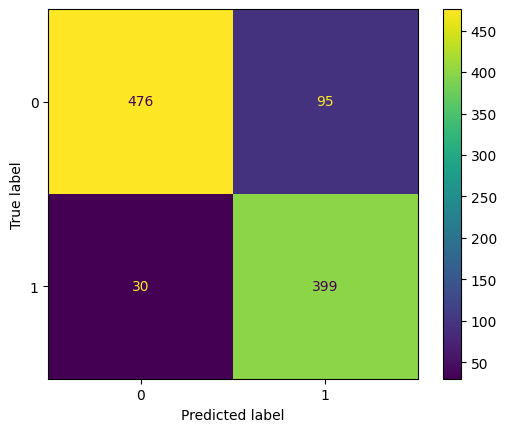


Logistic Regression Results: Dataset 2 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8784
Mean Precision: 0.8112
Mean Recall   : 0.9146
Mean F1-score : 0.8597

Feature Importance Ranking (Absolute Coefficient Magnitude)
                   Feature  Importance
0                  SMOKING    1.525749
1        THROAT_DISCOMFORT    1.175328
2          BREATHING_ISSUE    1.140644
3   SMOKING_FAMILY_HISTORY    0.774546
4            STRESS_IMMUNE    0.747416
5             ENERGY_LEVEL    0.675255
6    EXPOSURE_TO_POLLUTION    0.400234
7           FAMILY_HISTORY    0.228417
8     FINGER_DISCOLORATION    0.056415
9        OXYGEN_SATURATION    0.048125
10         CHEST_TIGHTNESS    0.043707
11           MENTAL_STRESS    0.028376
12     ALCOHOL_CONSUMPTION    0.026084
13                  GENDER    0.022382
14         IMMUNE_WEAKNESS    0.015085
15                     AGE    0.008182
16       LONG_TERM_ILLNESS    0.004759


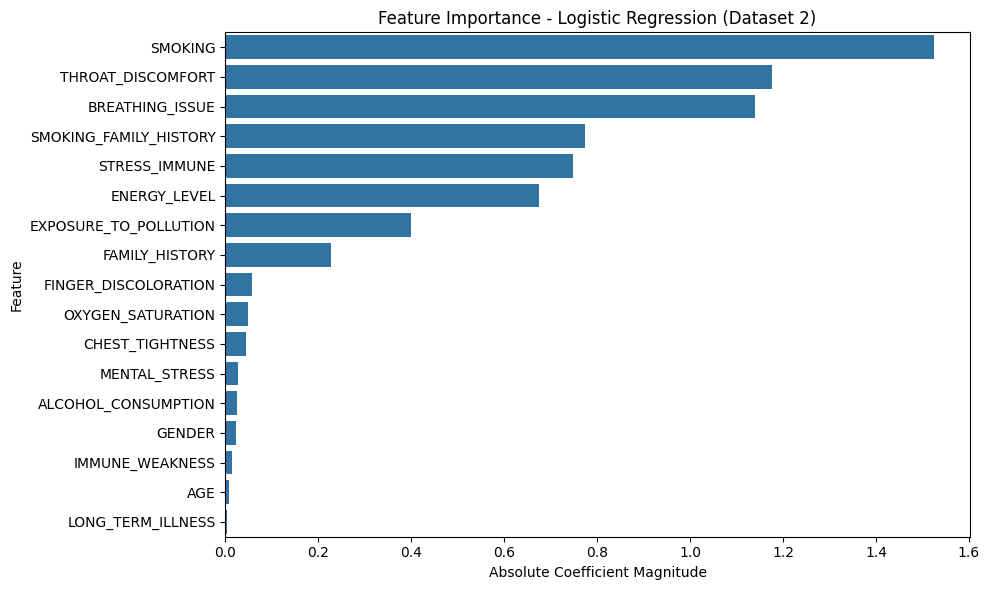


Individual Feature Results (5-Fold CV)
               Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0          BREATHING_ISSUE             1    0.5506   0.473846  0.930779   
1                  SMOKING             1    0.6830   0.567832  0.928816   
2        THROAT_DISCOMFORT             1    0.5912   0.499271  0.855173   
3     FINGER_DISCOLORATION             1    0.4938   0.417845  0.616573   
4          CHEST_TIGHTNESS             1    0.4940   0.417942  0.616111   
5            MENTAL_STRESS             1    0.5364   0.447877  0.593549   
6             ENERGY_LEVEL             1    0.5750   0.481753  0.573871   
7    EXPOSURE_TO_POLLUTION             1    0.5438   0.452914  0.573396   
8                      AGE             1    0.5040   0.412173  0.510560   
9      ALCOHOL_CONSUMPTION             1    0.4832   0.391886  0.499768   
10       OXYGEN_SATURATION             1    0.4996   0.405841  0.492899   
11                  GENDER             1    0.4910   0.39732

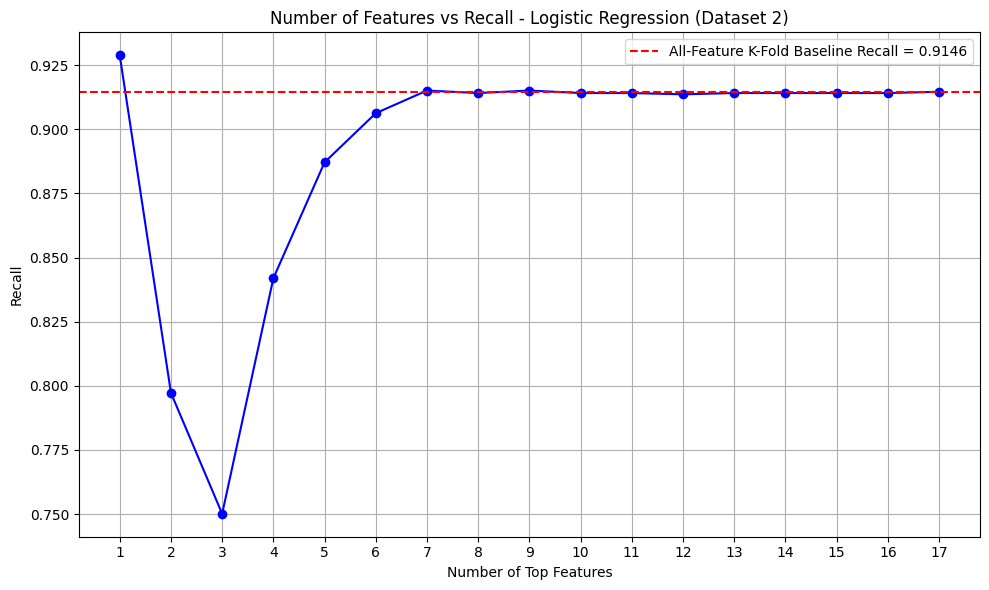

In [25]:
# LOGISTIC REGRESSION
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

print("DATASET 2: Lung Cancer Prediction Dataset")

pd.set_option('display.max_columns', None)

df2_lr = df_Lung_Cancer_Prediction_Dataset.copy()

df2_lr['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df2_lr['PULMONARY_DISEASE'])

for col in df2_lr.columns:
  if df2_lr[col].dtype == 'object':
      df2_lr[col] = LabelEncoder().fit_transform(df2_lr[col])

df2_lr.columns = df2_lr.columns.str.strip()

print("First 5 rows")
print(df2_lr.head())

print("\nColumn names:")
print(df2_lr.columns.tolist())

print("\nDataset info:")
df2_lr.info()

print("\nMissing values:")
print(df2_lr.isnull().sum())

for col in df2_lr.columns:
    if df2_lr[col].dtype == "object":
        df2_lr[col] = df2_lr[col].fillna(df2_lr[col].mode()[0])
    else:
        df2_lr[col] = df2_lr[col].fillna(df2_lr[col].median())

print("\nMissing values after filling:")
print(df2_lr.isnull().sum())


# Prepare features and target
X2 = df2_lr.drop(columns=['PULMONARY_DISEASE'])
y2 = df2_lr['PULMONARY_DISEASE']

# Scale features
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Logistic Regression model
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled,
    y2,
    test_size=0.2,
    random_state=42
)

model.fit(X_train2, y_train2)

y_pred2 = model.predict(X_test2)

print(classification_report(y_test2, y_pred2))

accuracy_lr = accuracy_score(y_test2, y_pred2)
f1_lr = f1_score(y_test2, y_pred2)
precision_lr = precision_score(y_test2, y_pred2)
recall_lr = recall_score(y_test2, y_pred2)

print(f"\nAccuracy: {accuracy_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")

cm_lr = confusion_matrix(y_test2, y_pred2)

print(cm_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=model.classes_
)
disp.plot()
plt.show()

# BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X2_scaled,
    y2,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results: Dataset 2 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE (using coefficients from Logistic Regression)
lr_model_full = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr_model_full.fit(X2_scaled, y2)

# Get absolute coefficients for feature importance
feature_importance_df = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": np.abs(lr_model_full.coef_[0])
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking (Absolute Coefficient Magnitude)")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Logistic Regression (Dataset 2)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
  X_single = X2[[feature]]

  # Scale the single feature
  scaler_single = StandardScaler()
  X_single_scaled = scaler_single.fit_transform(X_single)

  single_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
  )

  single_cv_results = cross_validate(
       single_model,
       X_single_scaled,
       y2,
       cv=cv,
       scoring=scoring,
       n_jobs=-1
  )

  individual_feature_results.append({
      "Feature_Set": feature,
      "Num_Features": 1,
      "Accuracy": single_cv_results["test_accuracy"].mean(),
      "Precision": single_cv_results["test_precision"].mean(),
      "Recall": single_cv_results["test_recall"].mean(),
      "F1-score": single_cv_results["test_f1"].mean()
  })


individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X2[selected_features]

    # Scale the top-k features
    scaler_topk = StandardScaler()
    X_topk_scaled = scaler_topk.fit_transform(X_topk)

    topk_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk_scaled,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X2.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)


# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o", color="blue")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Logistic Regression (Dataset 2)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# LOGISTIC REGRESSION RESULTS FOR FINAL COMPARISON
lr2_summary = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1-score": f1_lr,
    "CV Accuracy": baseline_accuracy_cv,
    "CV Precision": baseline_precision_cv,
    "CV Recall": baseline_recall_cv,
    "CV F1-score": baseline_f1_cv
}

cm_lr2 = cm_lr.copy()
topk_lr2_results_df = topk_results_df.copy()

First 5 rows:
   AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURATION  \
0                0                    1            

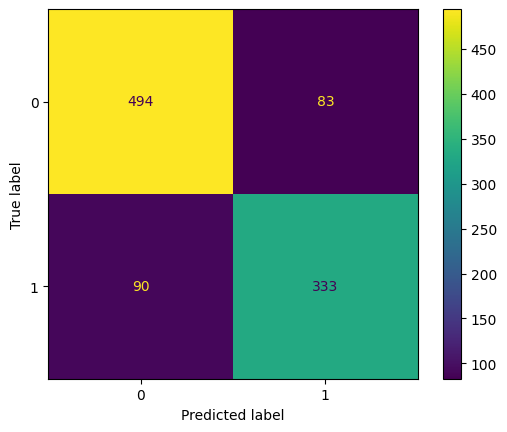


Decision Tree Results: Dataset 2 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8318
Mean Precision: 0.7966
Mean Recall   : 0.7889
Mean F1-score : 0.7924

Feature Importance Ranking
                   Feature  Importance
0                  SMOKING    0.236846
1             ENERGY_LEVEL    0.150062
2        THROAT_DISCOMFORT    0.123132
3          BREATHING_ISSUE    0.106454
4        OXYGEN_SATURATION    0.094265
5            STRESS_IMMUNE    0.081985
6                      AGE    0.061188
7           FAMILY_HISTORY    0.058305
8    EXPOSURE_TO_POLLUTION    0.038133
9          CHEST_TIGHTNESS    0.010943
10                  GENDER    0.007353
11     ALCOHOL_CONSUMPTION    0.007117
12           MENTAL_STRESS    0.005961
13         IMMUNE_WEAKNESS    0.005338
14    FINGER_DISCOLORATION    0.005280
15       LONG_TERM_ILLNESS    0.004573
16  SMOKING_FAMILY_HISTORY    0.003064


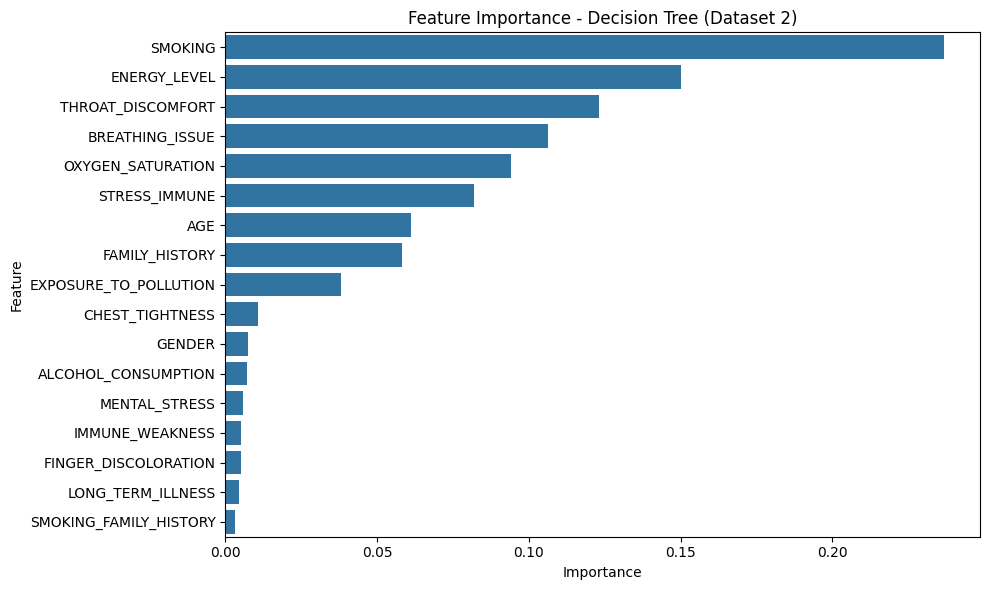


Individual Feature Results (5-Fold CV)
               Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0          BREATHING_ISSUE             1    0.5506   0.473846  0.930779   
1                  SMOKING             1    0.6830   0.567832  0.928816   
2        THROAT_DISCOMFORT             1    0.5912   0.499271  0.855173   
3     FINGER_DISCOLORATION             1    0.4938   0.417845  0.616573   
4          CHEST_TIGHTNESS             1    0.4940   0.417942  0.616111   
5            MENTAL_STRESS             1    0.5364   0.447877  0.593549   
6    EXPOSURE_TO_POLLUTION             1    0.5438   0.452914  0.573396   
7      ALCOHOL_CONSUMPTION             1    0.4832   0.391886  0.499768   
8                   GENDER             1    0.4910   0.397320  0.484042   
9          IMMUNE_WEAKNESS             1    0.5794   0.483254  0.468350   
10                     AGE             1    0.5010   0.401861  0.462419   
11       LONG_TERM_ILLNESS             1    0.5174   0.41448

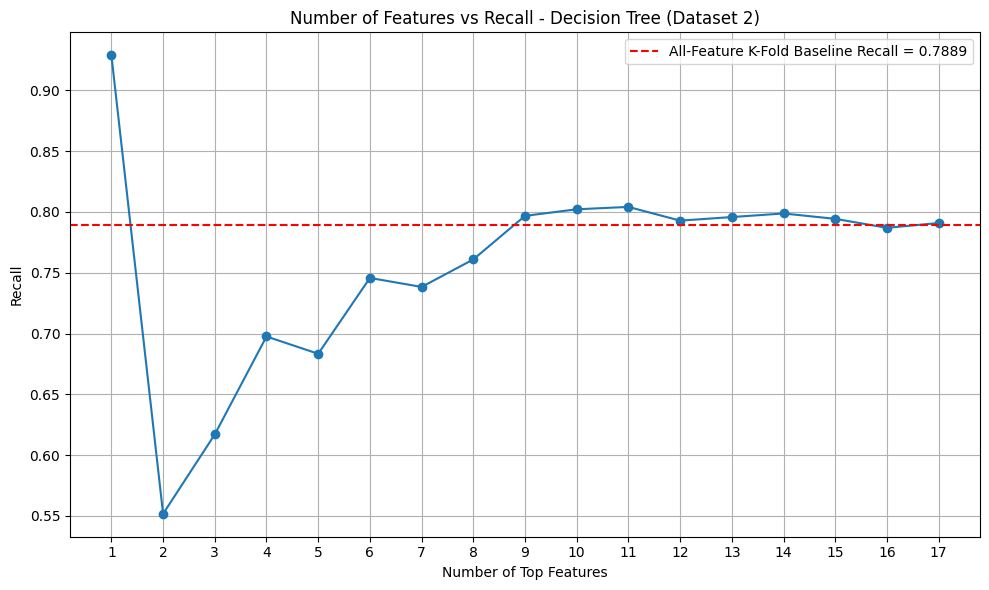

In [27]:
# DECISION TREE
import sklearn
from sklearn import tree #https://scikit-learn.org/stable/modules/tree.html
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder #https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
import matplotlib.pyplot as plt
import seaborn as sns

df2_dt = df_Lung_Cancer_Prediction_Dataset.copy()

# Clean column names
df2_dt.columns = df2_dt.columns.str.strip()

print("First 5 rows:")
print(df2_dt.head())

print("\nColumn names:")
print(df2_dt.columns.tolist())

print("\nDataset info:")
df2_dt.info()

print("\nMissing values:")
print(df2_dt.isnull().sum())


# FILL MISSING VALUES
for col in df2_dt.columns:
    if df2_dt[col].dtype == "object":
        df2_dt[col] = df2_dt[col].fillna(df2_dt[col].mode()[0])
    else:
        df2_dt[col] = df2_dt[col].fillna(df2_dt[col].median())

print("\nMissing values after filling:")
print(df2_dt.isnull().sum())

#ENCODING
df2_dt['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df2_dt['PULMONARY_DISEASE'])

X2 = df2_dt.drop(columns=['PULMONARY_DISEASE'])
y2 = df2_dt['PULMONARY_DISEASE']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2)

model.fit(X_train, y_train)

from sklearn.metrics import classification_report

y_pred_dt = model.predict(X_test)

print(classification_report(y_test, y_pred_dt))

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print(f"\nAccuracy: {accuracy_dt:.4f}")

print(f"F1-Score: {f1_dt:.4f}")

print(f"Precision: {precision_dt:.4f}")

print(f"Recall: {recall_dt:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X2,
    y2,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 2 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

#FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X2, y2)

feature_importance_df = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 2)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X2[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X2[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y2,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X2.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Decision Tree (Dataset 2)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# DECISION TREE RESULTS FOR FINAL COMPARISON
dt2_summary = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_dt,
    "Precision": precision_dt,
    "Recall": recall_dt,
    "F1-score": f1_dt,
    "CV Accuracy": baseline_accuracy_cv,
    "CV Precision": baseline_precision_cv,
    "CV Recall": baseline_recall_cv,
    "CV F1-score": baseline_f1_cv
}

cm_dt2 = cm_dt.copy()
topk_dt2_results_df = topk_results_df.copy()

DATASET 2: Lung Cancer Prediction Dataset - Random Forest
First 5 rows:
   AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURAT

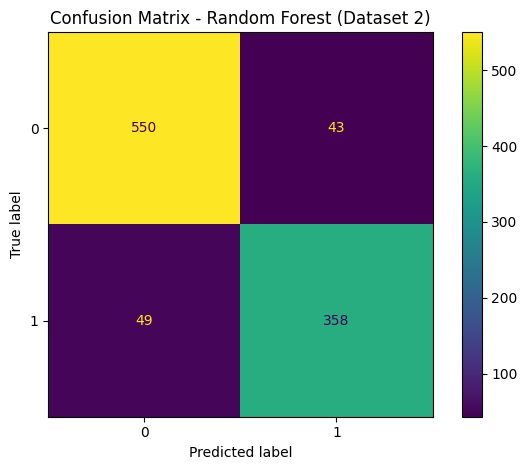


Random Forest Results: Dataset 2 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.9098
Mean Precision: 0.8995
Mean Recall   : 0.8768
Mean F1-score : 0.8879

Feature Importance Ranking
                   Feature  Importance
0                  SMOKING    0.219115
1             ENERGY_LEVEL    0.151450
2        THROAT_DISCOMFORT    0.112749
3          BREATHING_ISSUE    0.103667
4        OXYGEN_SATURATION    0.094590
5                      AGE    0.079579
6   SMOKING_FAMILY_HISTORY    0.044630
7            STRESS_IMMUNE    0.035720
8    EXPOSURE_TO_POLLUTION    0.032803
9           FAMILY_HISTORY    0.019014
10         IMMUNE_WEAKNESS    0.018765
11           MENTAL_STRESS    0.016215
12                  GENDER    0.015286
13       LONG_TERM_ILLNESS    0.014853
14    FINGER_DISCOLORATION    0.013962
15         CHEST_TIGHTNESS    0.013850
16     ALCOHOL_CONSUMPTION    0.013754


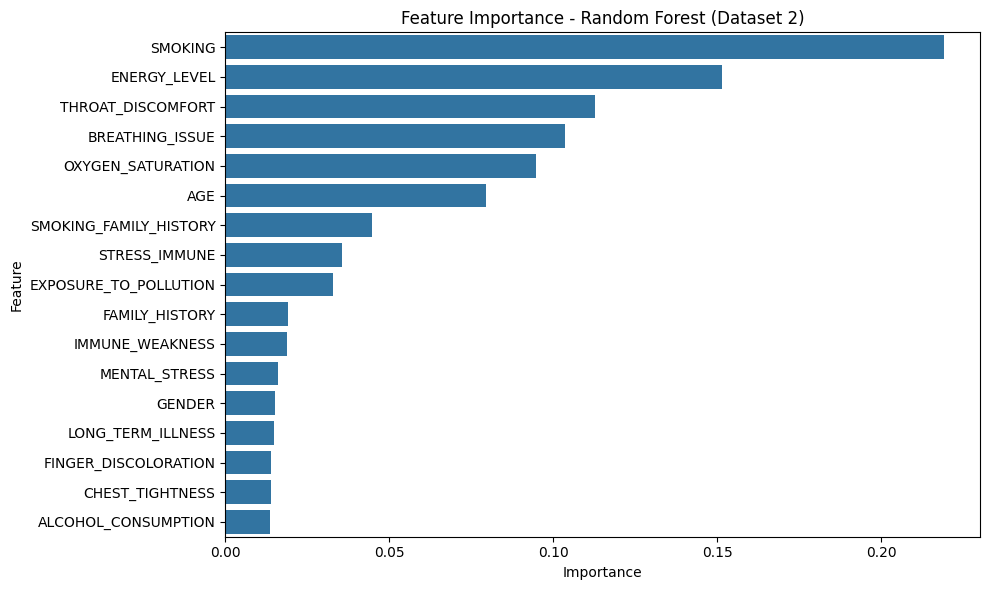


Individual Feature Results (5-Fold CV)
               Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0          BREATHING_ISSUE             1    0.5506   0.473846  0.930779   
1                  SMOKING             1    0.6830   0.567832  0.928816   
2        THROAT_DISCOMFORT             1    0.5912   0.499271  0.855173   
3     FINGER_DISCOLORATION             1    0.4938   0.417845  0.616573   
4          CHEST_TIGHTNESS             1    0.4940   0.417942  0.616111   
5            MENTAL_STRESS             1    0.5364   0.447877  0.593549   
6    EXPOSURE_TO_POLLUTION             1    0.5438   0.452914  0.573396   
7                   GENDER             1    0.4910   0.397320  0.484042   
8          IMMUNE_WEAKNESS             1    0.5794   0.483254  0.468350   
9        LONG_TERM_ILLNESS             1    0.5174   0.414487  0.446746   
10                     AGE             1    0.5022   0.399891  0.443772   
11            ENERGY_LEVEL             1    0.5344   0.42871

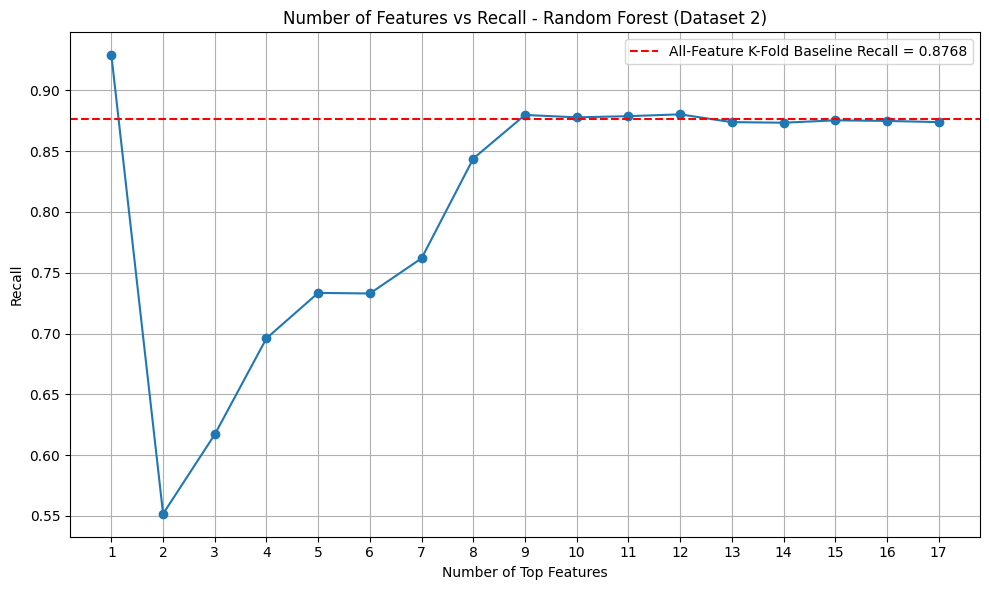

In [28]:
# RANDOM FOREST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

print("DATASET 2: Lung Cancer Prediction Dataset - Random Forest")

pd.set_option('display.max_columns', None)

df2_rf = df_Lung_Cancer_Prediction_Dataset.copy()

# Clean column names
df2_rf.columns = df2_rf.columns.str.strip()

# DEFINE TARGET COLUMN
target_col = "PULMONARY_DISEASE"

# Convert target to 0/1 if needed
df2_rf[target_col] = df2_rf[target_col].astype(str).str.strip().str.upper().map({
    "NO": 0,
    "YES": 1,
    "0": 0,
    "1": 1
})

print("First 5 rows:")
print(df2_rf.head())

print("\nColumn names:")
print(df2_rf.columns.tolist())

print("\nDataset info:")
df2_rf.info()

print("\nMissing values:")
print(df2_rf.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df2_rf.columns:
    if col != target_col and df2_rf[col].dtype == "object":
        le = LabelEncoder()
        df2_rf[col] = le.fit_transform(df2_rf[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
X2_rf = df2_rf.drop(columns=[target_col])
y2_rf = df2_rf[target_col]

print("\nClass distribution:")
print(y2_rf.value_counts())

print("\nClass distribution meaning:")
print("0 = NO")
print("1 = YES")

print("\nClass distribution (proportion):")
print(y2_rf.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X2_rf_train, X2_rf_test, y2_rf_train, y2_rf_test = train_test_split(
    X2_rf,
    y2_rf,
    test_size=0.2,
    random_state=42,
    stratify=y2_rf
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X2_rf_train, y2_rf_train)
y2_rf_pred = rf_model_split.predict(X2_rf_test)

accuracy_rf = accuracy_score(y2_rf_test, y2_rf_pred)
precision_rf = precision_score(y2_rf_test, y2_rf_pred, zero_division=0)
recall_rf = recall_score(y2_rf_test, y2_rf_pred, zero_division=0)
f1_rf = f1_score(y2_rf_test, y2_rf_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 2 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

cm_rf = confusion_matrix(y2_rf_test, y2_rf_pred)

print("\nConfusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[0, 1]
)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 2)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_rf_cv_results = cross_validate(
    baseline_rf_model,
    X2_rf,
    y2_rf,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_rf_cv = baseline_rf_cv_results["test_accuracy"].mean()
baseline_precision_rf_cv = baseline_rf_cv_results["test_precision"].mean()
baseline_recall_rf_cv = baseline_rf_cv_results["test_recall"].mean()
baseline_f1_rf_cv = baseline_rf_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 2 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_rf_cv:.4f}")
print(f"Mean Precision: {baseline_precision_rf_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_rf_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_rf_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X2_rf, y2_rf)

feature_importance_rf_df = pd.DataFrame({
    "Feature": X2_rf.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_rf_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_rf_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 2)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_rf_results = []

for feature in feature_importance_rf_df["Feature"]:
    X_single_rf = X2_rf[[feature]]

    single_rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_rf_cv_results = cross_validate(
        single_rf_model,
        X_single_rf,
        y2_rf,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_rf_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_rf_cv_results["test_accuracy"].mean(),
        "Precision": single_rf_cv_results["test_precision"].mean(),
        "Recall": single_rf_cv_results["test_recall"].mean(),
        "F1-score": single_rf_cv_results["test_f1"].mean()
    })

individual_feature_rf_df = pd.DataFrame(individual_feature_rf_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_rf_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_rf_features = feature_importance_rf_df["Feature"].tolist()
topk_rf_results = []

for k in range(1, len(ranked_rf_features) + 1):
    selected_rf_features = ranked_rf_features[:k]
    X_topk_rf = X2_rf[selected_rf_features]

    topk_rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_rf_cv_results = cross_validate(
        topk_rf_model,
        X_topk_rf,
        y2_rf,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_rf_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_rf_features),
        "Accuracy": topk_rf_cv_results["test_accuracy"].mean(),
        "Precision": topk_rf_cv_results["test_precision"].mean(),
        "Recall": topk_rf_cv_results["test_recall"].mean(),
        "F1-score": topk_rf_cv_results["test_f1"].mean()
    })

topk_rf_results_df = pd.DataFrame(topk_rf_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_rf_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_rf_row = pd.DataFrame([{
    "Num_Features": X2_rf.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_rf_cv,
    "Precision": baseline_precision_rf_cv,
    "Recall": baseline_recall_rf_cv,
    "F1-score": baseline_f1_rf_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_rf_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_rf_results_df["Num_Features"], topk_rf_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_rf_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_rf_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 2)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_rf_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# RANDOM FOREST RESULTS FOR FINAL COMPARISON
rf2_summary = {
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-score": f1_rf,
    "CV Accuracy": baseline_accuracy_rf_cv,
    "CV Precision": baseline_precision_rf_cv,
    "CV Recall": baseline_recall_rf_cv,
    "CV F1-score": baseline_f1_rf_cv
}

cm_rf2 = cm_rf.copy()
topk_rf2_results_df = topk_rf_results_df.copy()

In [29]:
# FINAL MODEL COMPARISON - DATASET 2

model_comparison_dataset2_df = pd.DataFrame([
    lr2_summary,
    dt2_summary,
    rf2_summary
])

print("Model Performance on Test Data - Dataset 2")
display(model_comparison_dataset2_df[[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]])

print("\n5-Fold Cross-Validation Performance - Dataset 2")
display(model_comparison_dataset2_df[[
    "Model",
    "CV Accuracy",
    "CV Precision",
    "CV Recall",
    "CV F1-score"
]])

Model Performance on Test Data - Dataset 2


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.875,0.807692,0.930070,0.864572
1,Decision Tree,0.827,0.800481,0.787234,0.793802
2,Random Forest,0.908,0.892768,0.879607,0.886139



5-Fold Cross-Validation Performance - Dataset 2


,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score
0,Logistic Regression,0.8784,0.811248,0.914579,0.859737
1,Decision Tree,0.8318,0.796596,0.788899,0.792413
2,Random Forest,0.9098,0.899452,0.876786,0.887898


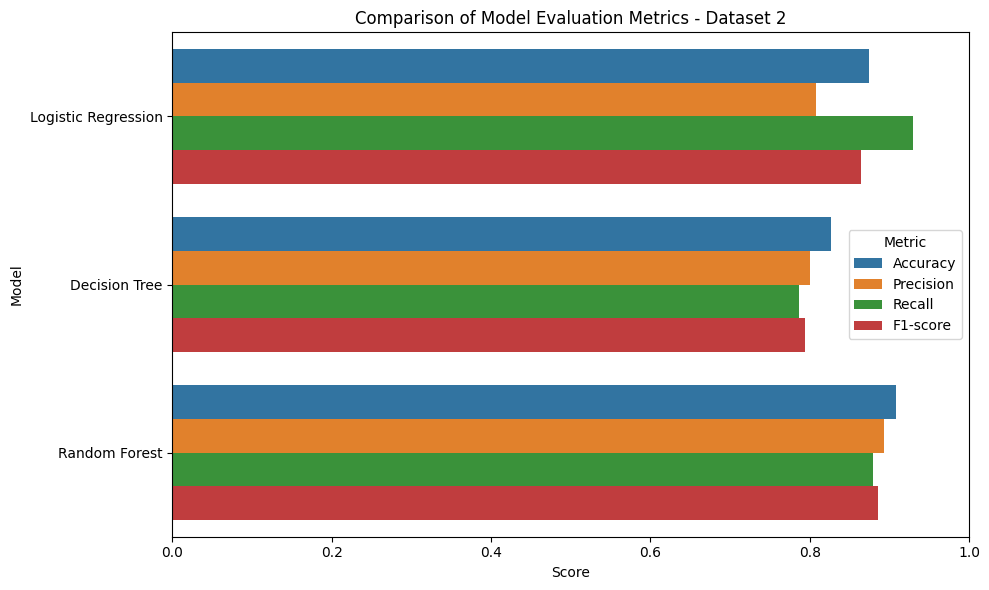

In [30]:
# BAR CHART: MODEL EVALUATION METRICS - DATASET 2

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]

model_comparison_dataset2_long = model_comparison_dataset2_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_comparison_dataset2_long,
    x="Score",
    y="Model",
    hue="Metric"
)

plt.title("Comparison of Model Evaluation Metrics - Dataset 2")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

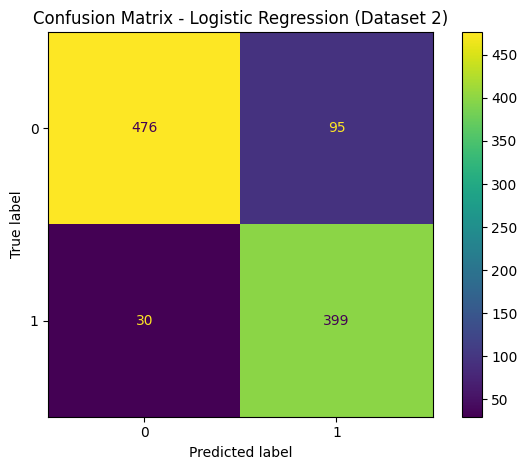

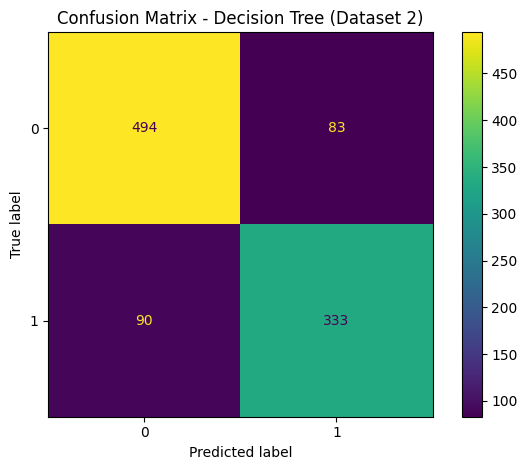

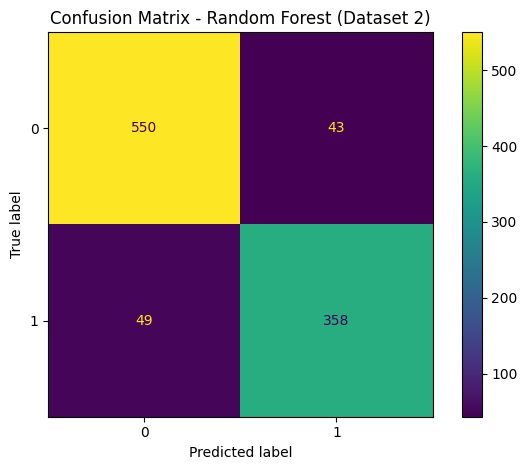

In [31]:
# CONFUSION MATRICES FOR EACH MODEL - DATASET 2

confusion_matrices_dataset2 = {
    "Logistic Regression": cm_lr2,
    "Decision Tree": cm_dt2,
    "Random Forest": cm_rf2
}

for model_name, matrix in confusion_matrices_dataset2.items():
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[0, 1]
    )
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name} (Dataset 2)")
    plt.tight_layout()
    plt.show()

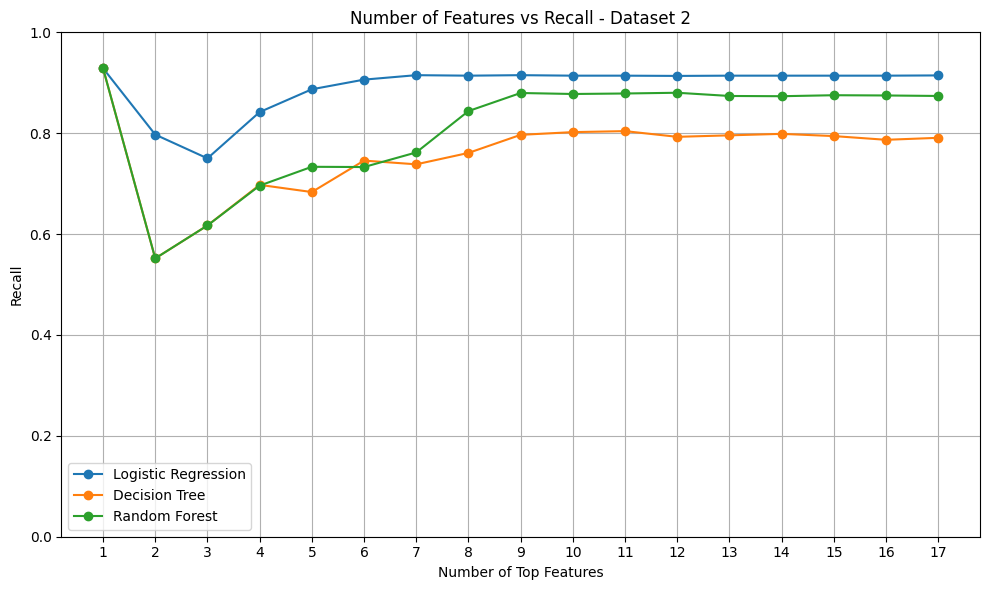

In [32]:
# FINAL GRAPH: NUMBER OF FEATURES VS RECALL FOR ALL MODELS - DATASET 2

plt.figure(figsize=(10, 6))

plt.plot(
    topk_lr2_results_df["Num_Features"],
    topk_lr2_results_df["Recall"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    topk_dt2_results_df["Num_Features"],
    topk_dt2_results_df["Recall"],
    marker="o",
    label="Decision Tree"
)

plt.plot(
    topk_rf2_results_df["Num_Features"],
    topk_rf2_results_df["Recall"],
    marker="o",
    label="Random Forest"
)

max_features = max(
    topk_lr2_results_df["Num_Features"].max(),
    topk_dt2_results_df["Num_Features"].max(),
    topk_rf2_results_df["Num_Features"].max()
)

plt.title("Number of Features vs Recall - Dataset 2")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, max_features + 1))
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()